In [ ]:
from google.colab import files
import zipfile
import os
import shutil

# Upload the downloaded dataset
print("Please upload the Art Images dataset zip file:")
uploaded = files.upload()

# Extract the dataset
for filename in uploaded.keys():
    if filename.endswith('.zip'):
        print(f"📦 Extracting {filename}...")
        with zipfile.ZipFile(filename, 'r') as zip_ref:
            zip_ref.extractall('/content/')
        print("✅ Extraction completed!")

# Find the extracted dataset
dataset_path = None
possible_paths = [
    '/content/dataset',
    '/content/art-images-drawings-painting-sculpture-engraving',
    '/content/Art Images',
    '/content/images'
]

for path in possible_paths:
    if os.path.exists(path):
        dataset_path = path
        break

if dataset_path:
    print(f"🎯 Found dataset at: {dataset_path}")
else:
    # List all directories to help find the dataset
    print("🔍 Searching for dataset...")
    for item in os.listdir('/content/'):
        item_path = os.path.join('/content/', item)
        if os.path.isdir(item_path):
            print(f"📁 {item}")
            # Check if this directory contains images
            image_count = 0
            for root, dirs, files in os.walk(item_path):
                for file in files:
                    if file.lower().endswith(('.jpg', '.jpeg', '.png')):
                        image_count += 1
            if image_count > 0:
                print(f"   🖼️  Found {image_count} images")
                dataset_path = item_path
                break

print(f"📍 Using dataset path: {dataset_path}")

Please upload the Art Images dataset zip file:


Saving archive (1).zip to archive (1).zip
📦 Extracting archive (1).zip...
✅ Extraction completed!
🎯 Found dataset at: /content/dataset
📍 Using dataset path: /content/dataset


In [ ]:
import os
import zipfile
from google.colab import files

# Let's properly explore what was downloaded
print("🔍 Exploring the actual dataset structure...")

def find_dataset_structure():
    # List everything in /content
    print("Contents of /content:")
    for item in os.listdir('/content/'):
        item_path = os.path.join('/content/', item)
        if os.path.isdir(item_path):
            print(f"📁 {item}/")
            # Explore this directory
            try:
                sub_items = os.listdir(item_path)
                for sub_item in sub_items[:5]:  # Show first 5 items
                    sub_path = os.path.join(item_path, sub_item)
                    if os.path.isdir(sub_path):
                        print(f"   📁 {sub_item}/")
                        # Count images in this subdirectory
                        images = [f for f in os.listdir(sub_path) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
                        if images:
                            print(f"      🖼️  {len(images)} images")
                    else:
                        if sub_item.lower().endswith(('.jpg', '.jpeg', '.png')):
                            print(f"   🖼️  {sub_item}")
            except Exception as e:
                print(f"   ❌ Could not read: {e}")
        else:
            if item.endswith('.zip'):
                print(f"📦 {item} (zip file)")
            elif item.lower().endswith(('.jpg', '.jpeg', '.png')):
                print(f"🖼️  {item}")

find_dataset_structure()

🔍 Exploring the actual dataset structure...
Contents of /content:
📁 .config/
📁 musemart/
   📁 dataset_updated/
📁 drive/
   📁 MyDrive/
      🖼️  4 images
   📁 .shortcut-targets-by-id/
   📁 .Trash-0/
   📁 .Encrypted/
📁 dataset/
   📁 dataset_updated/
📦 archive (1).zip (zip file)
📁 sample_data/


In [ ]:
# Check common dataset structures for this specific dataset
common_structures = [
    '/content/dataset',
    '/content/art-images-drawings-painting-sculpture-engraving',
    '/content/archive',
    '/content/images',
    '/content/data'
]

print("\n🔎 Checking common dataset paths:")
for path in common_structures:
    if os.path.exists(path):
        print(f"✅ Found: {path}")
        # Show what's inside
        try:
            contents = os.listdir(path)
            print(f"   Contents: {contents[:10]}")  # Show first 10 items
            # Count total images
            image_count = 0
            for root, dirs, files in os.walk(path):
                for file in files:
                    if file.lower().endswith(('.jpg', '.jpeg', '.png')):
                        image_count += 1
            print(f"   Total images: {image_count}")
        except Exception as e:
            print(f"   ❌ Error reading: {e}")
    else:
        print(f"❌ Not found: {path}")


🔎 Checking common dataset paths:
✅ Found: /content/dataset
   Contents: ['dataset_updated']
   Total images: 8577
❌ Not found: /content/art-images-drawings-painting-sculpture-engraving
❌ Not found: /content/archive
❌ Not found: /content/images
❌ Not found: /content/data


In [ ]:
import os
import matplotlib.pyplot as plt
import numpy as np

# The dataset is at /content/dataset/dataset_updated
dataset_path = '/content/dataset/dataset_updated'

print(f"🔍 Exploring: {dataset_path}")

if os.path.exists(dataset_path):
    print("✅ Dataset found!")

    # List what's inside
    contents = os.listdir(dataset_path)
    print(f"📁 Contents: {contents}")

    # Check if these are directories (art styles)
    art_styles = []
    for item in contents:
        item_path = os.path.join(dataset_path, item)
        if os.path.isdir(item_path):
            # Count images in this directory
            images = [f for f in os.listdir(item_path) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
            art_styles.append((item, len(images)))
            print(f"🎨 {item}: {len(images)} images")

    print(f"\n📊 Total art styles: {len(art_styles)}")

else:
    print("❌ Dataset path not found. Let's check the parent directory:")
    parent_path = '/content/dataset'
    if os.path.exists(parent_path):
        print(f"Contents of {parent_path}: {os.listdir(parent_path)}")

🔍 Exploring: /content/dataset/dataset_updated
✅ Dataset found!
📁 Contents: ['validation_set', 'training_set']
🎨 validation_set: 0 images
🎨 training_set: 0 images

📊 Total art styles: 2


In [ ]:
import os
import matplotlib.pyplot as plt
import numpy as np

# Explore the training_set and validation_set
training_path = '/content/dataset/dataset_updated/training_set'
validation_path = '/content/dataset/dataset_updated/validation_set'

print("🔍 Exploring dataset structure...")

def explore_category_structure(path, set_name):
    print(f"\n📁 {set_name}:")
    if os.path.exists(path):
        categories = [d for d in os.listdir(path) if os.path.isdir(os.path.join(path, d))]
        print(f"Categories found: {categories}")

        for category in categories:
            category_path = os.path.join(path, category)
            images = [f for f in os.listdir(category_path) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
            print(f"🎨 {category}: {len(images)} images")

            # Show first few image names
            if images:
                print(f"   Sample: {images[:3]}")
    else:
        print(f"❌ {set_name} path not found: {path}")

explore_category_structure(training_path, "Training Set")
explore_category_structure(validation_path, "Validation Set")

🔍 Exploring dataset structure...

📁 Training Set:
Categories found: ['painting', 'drawings', 'engraving', 'iconography', 'sculpture']
🎨 painting: 2042 images
   Sample: ['0573.jpg', '0074.jpg', '1957.jpg']
🎨 drawings: 1107 images
   Sample: ['i - 176.jpeg', 'i - 592.jpeg', 'i - 306.jpeg']
🎨 engraving: 757 images
   Sample: ['i - 176.jpeg', 'i - 204.jpeg', 'i - 592.jpeg']
🎨 iconography: 2077 images
   Sample: ['i - 176.jpeg', '317.jpg', '732.jpg']
🎨 sculpture: 1738 images
   Sample: ['i - 176.jpeg', 'i - 592.jpeg', 'i - 306.jpeg']

📁 Validation Set:
Categories found: ['painting', 'drawings', 'engraving', 'iconography', 'sculpture']
🎨 painting: 228 images
   Sample: ['2014.jpg', '1802.jpg', '2352.jpg']
🎨 drawings: 122 images
   Sample: ['i - 1131.jpeg', 'images (64).jpeg', 'images (38).jpeg']
🎨 engraving: 84 images
   Sample: ['i - 446.jpeg', '330.jpg', 'i - 358.jpeg']
🎨 iconography: 231 images
   Sample: ['503.jpg', 'i - 204.jpeg', 'i - 819.jpeg']
🎨 sculpture: 191 images
   Sample: ['i 

🎨 Art categories: ['painting', 'drawings', 'engraving', 'iconography', 'sculpture']
📂 painting: 2042 images available
📂 drawings: 1107 images available
📂 engraving: 757 images available
📂 iconography: 2077 images available


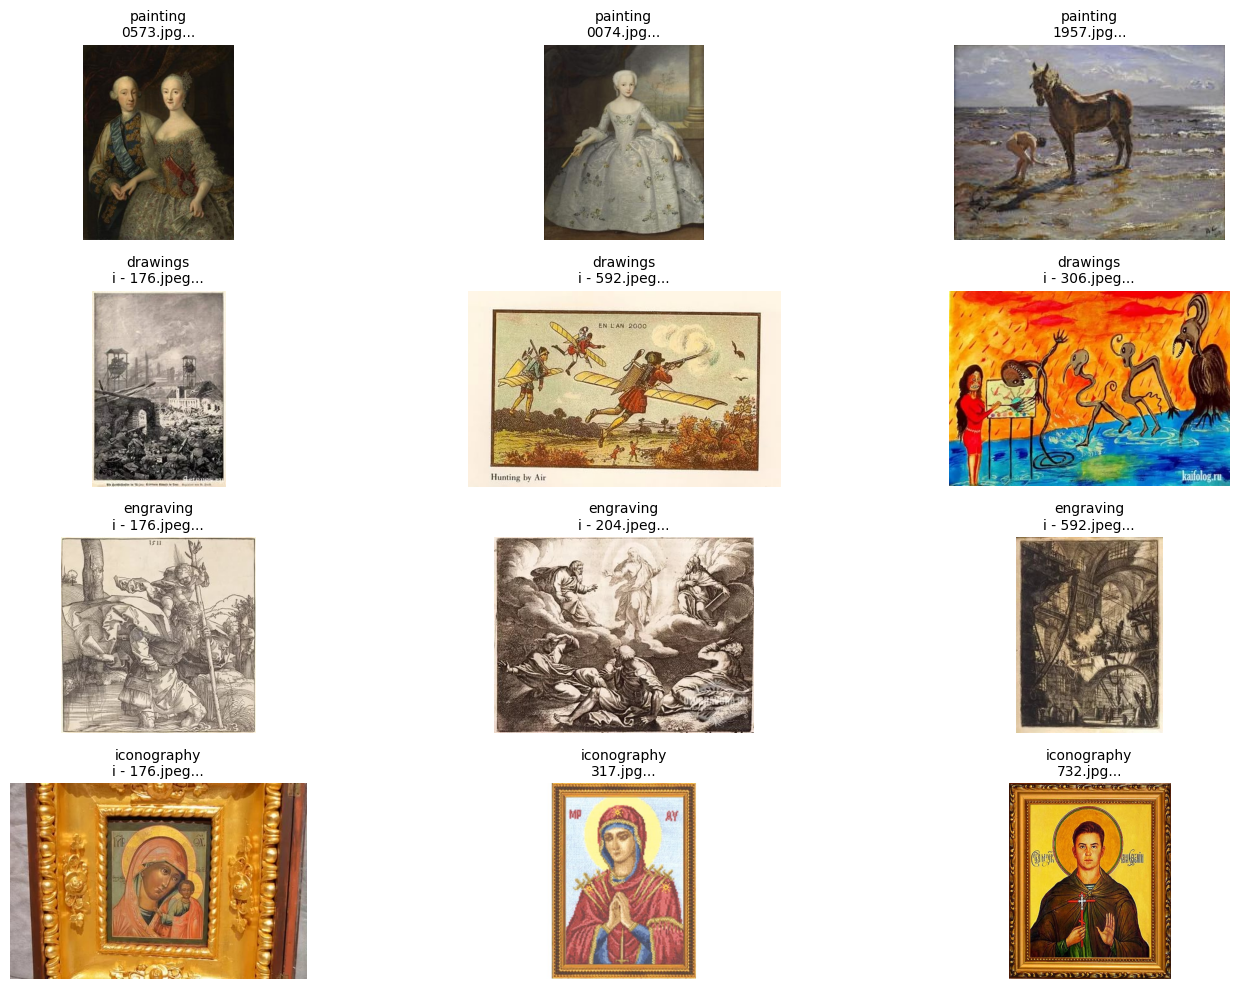

In [ ]:
def show_training_samples():
    """Show sample images from training set"""
    training_path = '/content/dataset/dataset_updated/training_set'

    if os.path.exists(training_path):
        categories = [d for d in os.listdir(training_path) if os.path.isdir(os.path.join(training_path, d))]

        print(f"🎨 Art categories: {categories}")

        plt.figure(figsize=(15, 10))
        plot_index = 1

        for category in categories[:4]:  # Show first 4 categories
            category_path = os.path.join(training_path, category)
            images = [f for f in os.listdir(category_path) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]

            print(f"📂 {category}: {len(images)} images available")

            for i in range(min(3, len(images))):  # Show 3 samples per category
                img_path = os.path.join(category_path, images[i])
                try:
                    img = plt.imread(img_path)
                    plt.subplot(4, 3, plot_index)
                    plt.imshow(img)
                    plt.title(f'{category}\n{images[i][:15]}...', fontsize=10)
                    plt.axis('off')
                    plot_index += 1
                except Exception as e:
                    print(f"❌ Could not load {img_path}: {e}")

        plt.tight_layout()
        plt.show()
    else:
        print("❌ Training set path not found")

show_training_samples()


In [ ]:
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# Since the dataset is already split, we'll use the training_set for training
# and validation_set for validation
training_path = '/content/dataset/dataset_updated/training_set'
validation_path = '/content/dataset/dataset_updated/validation_set'

print("🎯 Setting up data generators with pre-split dataset...")

# Image parameters
IMG_HEIGHT = 224
IMG_WIDTH = 224
BATCH_SIZE = 32

# Data augmentation for training (only on training set)
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    horizontal_flip=True,
    zoom_range=0.2,
    shear_range=0.1,
    fill_mode='nearest'
)

# No augmentation for validation
val_datagen = ImageDataGenerator(rescale=1./255)

print("🔄 Creating data generators...")

# Training data generator
train_generator = train_datagen.flow_from_directory(
    training_path,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=True
)

# Validation data generator
validation_generator = val_datagen.flow_from_directory(
    validation_path,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False  # No need to shuffle validation data
)

# Get class information
class_names = list(train_generator.class_indices.keys())
num_classes = len(class_names)

print(f"\n✅ Data generators setup complete!")
print(f"🎨 Art categories: {class_names}")
print(f"📊 Training samples: {train_generator.samples}")
print(f"📊 Validation samples: {validation_generator.samples}")
print(f"🎯 Number of classes: {num_classes}")

🎯 Setting up data generators with pre-split dataset...
🔄 Creating data generators...
Found 7721 images belonging to 5 classes.
Found 856 images belonging to 5 classes.

✅ Data generators setup complete!
🎨 Art categories: ['drawings', 'engraving', 'iconography', 'painting', 'sculpture']
📊 Training samples: 7721
📊 Validation samples: 856
🎯 Number of classes: 5


In [ ]:
def create_art_cnn_model(num_classes):
    model = keras.Sequential([
        # First convolutional block
        layers.Conv2D(32, (3, 3), activation='relu', padding='same',
                     input_shape=(IMG_HEIGHT, IMG_WIDTH, 3)),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2, 2),
        layers.Dropout(0.25),

        # Second convolutional block
        layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2, 2),
        layers.Dropout(0.25),

        # Third convolutional block
        layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2, 2),
        layers.Dropout(0.25),

        # Fourth convolutional block
        layers.Conv2D(256, (3, 3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2, 2),
        layers.Dropout(0.25),

        # Classifier
        layers.Flatten(),
        layers.Dense(512, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.5),
        layers.Dense(256, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.3),
        layers.Dense(num_classes, activation='softmax')
    ])

    return model

# Create model
print("🛠️ Building CNN model...")
model = create_art_cnn_model(num_classes)

# Compile model
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("✅ Model built successfully!")
model.summary()

🛠️ Building CNN model...
✅ Model built successfully!


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 28, 28, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 28, 28, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 50176)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 512)            │    25,690,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_12          │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_13          │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │             

 Total params: 26,216,645 (100.01 MB)

 Trainable params: 26,214,149 (100.00 MB)

 Non-trainable params: 2,496 (9.75 KB)

In [ ]:
import os
from PIL import Image
import shutil

def clean_dataset(dataset_path):
    """Remove corrupted images from the dataset"""
    print(f"🧹 Cleaning dataset: {dataset_path}")

    corrupted_count = 0
    total_images = 0

    for root, dirs, files in os.walk(dataset_path):
        for file in files:
            file_path = os.path.join(root, file)

            # Check if file has image extension
            if file.lower().endswith(('.jpg', '.jpeg', '.png', '.bmp')):
                total_images += 1

                try:
                    # Try to open the image to check if it's valid
                    with Image.open(file_path) as img:
                        img.verify()  # Verify it's a valid image
                except (IOError, SyntaxError, Exception) as e:
                    print(f"❌ Corrupted image: {file_path} - {e}")
                    # Remove corrupted file
                    os.remove(file_path)
                    corrupted_count += 1

    print(f"✅ Cleaning complete!")
    print(f"📊 Total images checked: {total_images}")
    print(f"🗑️  Corrupted images removed: {corrupted_count}")
    print(f"📈 Remaining images: {total_images - corrupted_count}")

# Clean both training and validation sets
training_path = '/content/dataset/dataset_updated/training_set'
validation_path = '/content/dataset/dataset_updated/validation_set'

clean_dataset(training_path)
clean_dataset(validation_path)

🧹 Cleaning dataset: /content/dataset/dataset_updated/training_set
✅ Cleaning complete!
📊 Total images checked: 7721
🗑️  Corrupted images removed: 0
📈 Remaining images: 7721
🧹 Cleaning dataset: /content/dataset/dataset_updated/validation_set
✅ Cleaning complete!
📊 Total images checked: 856
🗑️  Corrupted images removed: 0
📈 Remaining images: 856


In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Updated data generators with better error handling
def safe_image_generator(datagen, directory, **kwargs):
    """Create a safe image generator that skips corrupted files"""
    return datagen.flow_from_directory(
        directory,
        **kwargs,
        class_mode='categorical'
    )

# Image parameters
IMG_HEIGHT = 224
IMG_WIDTH = 224
BATCH_SIZE = 32

# Data augmentation for training
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    horizontal_flip=True,
    zoom_range=0.2,
    shear_range=0.1,
    fill_mode='nearest'
)

# No augmentation for validation
val_datagen = ImageDataGenerator(rescale=1./255)

print("🔄 Creating safe data generators...")

# Training data generator
train_generator = safe_image_generator(
    train_datagen,
    training_path,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    shuffle=True
)

# Validation data generator
validation_generator = safe_image_generator(
    val_datagen,
    validation_path,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    shuffle=False
)

# Get class information
class_names = list(train_generator.class_indices.keys())
num_classes = len(class_names)

print(f"\n✅ Safe data generators setup complete!")
print(f"🎨 Art categories: {class_names}")
print(f"📊 Training samples: {train_generator.samples}")
print(f"📊 Validation samples: {validation_generator.samples}")

🔄 Creating safe data generators...
Found 7721 images belonging to 5 classes.
Found 856 images belonging to 5 classes.

✅ Safe data generators setup complete!
🎨 Art categories: ['drawings', 'engraving', 'iconography', 'painting', 'sculpture']
📊 Training samples: 7721
📊 Validation samples: 856


In [ ]:
# Install and import required libraries
!pip install tensorflow matplotlib opencv-python pillow
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt
import numpy as np
import os
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping
import time

print("✅ Libraries imported successfully!")

# Dataset paths
training_path = '/content/dataset/dataset_updated/training_set'
validation_path = '/content/dataset/dataset_updated/validation_set'

# Image parameters
IMG_HEIGHT = 224
IMG_WIDTH = 224
BATCH_SIZE = 32

# Create data generators
print("🔄 Setting up data generators...")

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    horizontal_flip=True,
    zoom_range=0.2
)

val_datagen = ImageDataGenerator(rescale=1./255)

# Training data generator
train_generator = train_datagen.flow_from_directory(
    training_path,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=True
)

# Validation data generator
validation_generator = val_datagen.flow_from_directory(
    validation_path,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

# Get class information
class_names = list(train_generator.class_indices.keys())
num_classes = len(class_names)

print(f"\n✅ Data generators setup complete!")
print(f"🎨 Art categories: {class_names}")
print(f"📊 Training samples: {train_generator.samples}")
print(f"📊 Validation samples: {validation_generator.samples}")

✅ Libraries imported successfully!
🔄 Setting up data generators...
Found 7721 images belonging to 5 classes.
Found 856 images belonging to 5 classes.

✅ Data generators setup complete!
🎨 Art categories: ['drawings', 'engraving', 'iconography', 'painting', 'sculpture']
📊 Training samples: 7721
📊 Validation samples: 856


In [ ]:
# Define the model function
def create_simple_art_model(num_classes):
    model = keras.Sequential([
        # First convolutional block
        layers.Conv2D(32, (3, 3), activation='relu', padding='same',
                     input_shape=(IMG_HEIGHT, IMG_WIDTH, 3)),
        layers.MaxPooling2D(2, 2),
        layers.Dropout(0.25),

        # Second convolutional block
        layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
        layers.MaxPooling2D(2, 2),
        layers.Dropout(0.25),

        # Third convolutional block
        layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
        layers.MaxPooling2D(2, 2),
        layers.Dropout(0.25),

        # Classifier
        layers.Flatten(),
        layers.Dense(256, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(num_classes, activation='softmax')
    ])

    return model

# Create and compile model
print("🛠️ Building CNN model for 5 epochs...")
model = create_simple_art_model(num_classes=5)
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("✅ Model compiled!")
model.summary()

# Calculate steps
steps_per_epoch = max(1, train_generator.samples // BATCH_SIZE)
validation_steps = max(1, validation_generator.samples // BATCH_SIZE)

print(f"📈 Training configuration:")
print(f"🔄 Steps per epoch: {steps_per_epoch}")
print(f"🔄 Validation steps: {validation_steps}")
print(f"📦 Batch size: {BATCH_SIZE}")
print(f"⏱️  Epochs: 5 (Quick Test)")

# Train the model with 5 epochs
print("🚀 Starting training (5 epochs)...")
start_time = time.time()

history = model.fit(
    train_generator,
    steps_per_epoch=steps_per_epoch,
    epochs=5,
    validation_data=validation_generator,
    validation_steps=validation_steps,
    verbose=1
)

end_time = time.time()
training_time = (end_time - start_time) / 60
print(f"✅ Training completed in {training_time:.1f} minutes!")

🛠️ Building CNN model for 5 epochs...
✅ Model compiled!


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_10 (Conv2D)              │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_14 (Dropout)            │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_15 (Dropout)            │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_12 (MaxPooling2D) │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_16 (Dropout)            │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 100352)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 256)            │    25,690,368 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_17 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 5)              │         1,285 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 25,784,901 (98.36 MB)

 Trainable params: 25,784,901 (98.36 MB)

...

Epoch 1/5
 12/241 ━━━━━━━━━━━━━━━━━━━━ 22:47 6s/step - accuracy: 0.2001 - loss: 4.1071

/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


241/241 ━━━━━━━━━━━━━━━━━━━━ 1234s 5s/step - accuracy: 0.4749 - loss: 1.5415 - val_accuracy: 0.6959 - val_loss: 0.8553
Epoch 2/5
  1/241 ━━━━━━━━━━━━━━━━━━━━ 16:43 4s/step - accuracy: 0.6562 - loss: 0.9669

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


241/241 ━━━━━━━━━━━━━━━━━━━━ 38s 139ms/step - accuracy: 0.6562 - loss: 0.9669 - val_accuracy: 0.6923 - val_loss: 0.8264
Epoch 3/5
241/241 ━━━━━━━━━━━━━━━━━━━━ 1233s 5s/step - accuracy: 0.7082 - loss: 0.8068 - val_accuracy: 0.7416 - val_loss: 0.7028
Epoch 4/5
241/241 ━━━━━━━━━━━━━━━━━━━━ 47s 180ms/step - accuracy: 0.7812 - loss: 0.6685 - val_accuracy: 0.7524 - val_loss: 0.7121
Epoch 5/5
241/241 ━━━━━━━━━━━━━━━━━━━━ 1213s 5s/step - accuracy: 0.7300 - loss: 0.7473 - val_accuracy: 0.7007 - val_loss: 0.7464
✅ Training completed in 62.9 minutes!
